## Лабораторная работа №3: Классификация. Деревья решений

Выполнил студент группы 6401-010302D Смирнов Андрей Александрович

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import imageio as iio
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

### 1. Считать в `pandas.DataFrame` любой источник данных: CSV, JSON, Excel-файл, HTML-таблицу и т.п.

In [ ]:
# Датасет для бинарной классификации
df = pd.read_csv("/content/bank-full.csv", delimiter=';')
pd.set_option('display.max_columns', None)

df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


### 2. Датасет и подготовка данных:
   

#### **Привести описание датасета.**


Датасет содержит данные о результатах маркетинговой программы банка, полученных в ходе звонков клиентам.
Целевой признак:
- Бинарная классификация - y ('yes'/'no' согласился ли клиент на депозит)

| Признак | Описание | Тип / Единицы измерения  
   | --- | --- | --- |  
age |	Возраст	|	Числовой
job | Работа | Категориальный
marital | Семейный статус | Категориальный
education | Уровень образования | Категориальныый
default | Есть ли невыплаченный кредит | Бинарный
balance | Среднегодовой баланс | Числовой
housing | Есть ли ипотека | Бинарный
loan | Есть ли кредит для личного пользования | Бинарный
contact | Способ контакта | Категориальный
day | День последнего контакта | Дата
month | Месяц последнего контакта | Дата
duration | Длительность контакта | Числовой
campaign | Число контактов с клиентом за текущую компанию | Числовой
pdays | Число дней с последнего контакта | Числовой, -1 если это первый контакт
previous | Число контактов с клиентом за время предыдущих компаний | Числовой
poutcome | Исход предыдущей компании | Категориальный

- Осуществить предобработку данных (избавиться от `null`, убрать некоторые признаки и т.п.) &ndash; "подчистить данные".

In [ ]:
df = df.drop(columns=['duration', 'pdays', 'month', 'day']) # Убираем лишние признаки

df.dropna()

cat_cols = [var for var in df.columns if df[var].dtype == 'object']

len_max = max([len(col) for col in cat_cols])
for col in cat_cols:
    print(f"{col:<{len_max}} labels: {len(df[col].unique())}")

job       labels: 12
marital   labels: 3
education labels: 4
default   labels: 2
housing   labels: 2
loan      labels: 2
contact   labels: 3
poutcome  labels: 4
y         labels: 2


- Закодировать категориальные признаки при необходимости.

In [ ]:
# Кодируем бинарные категориальные переменные
for col in ['housing', 'loan', 'default', 'y']:
  df[col] = df[col].map({'no':0, 'yes':1}).astype(np.uint8)


# Кодируем небинарные категориальные переменные
for col in ['job', 'marital', 'education', 'contact', 'poutcome']:
  df_dummies = pd.get_dummies(df[col], prefix=col)
  df = df.drop(columns=col)
  df = df.join(df_dummies)

df

,age,default,balance,housing,loan,campaign,previous,y,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,1,0,0,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,44,0,29,1,0,1,0,0,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,True
2,33,0,2,1,1,1,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,True
3,47,0,1506,1,0,1,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True
4,33,0,1,0,0,1,0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,0,825,0,0,3,0,1,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,True
45207,71,0,1729,0,0,2,0,1,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True
45208,72,0,5715,0,0,5,3,1,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,True,False
45209,57,0,668,0,0,4,0,0,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True



- Разбить выборку на обучающую и тестовую.

In [ ]:
y = df['y']
X = df.drop('y', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

- Нормализовать данные.

In [ ]:
scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index= X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index= X_test.index)

X_train_scaled

,age,default,balance,housing,loan,campaign,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,education_primary,education_secondary,education_tertiary,education_unknown,contact_cellular,contact_telephone,contact_unknown,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
3344,0.298701,0.0,0.080511,1.0,0.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
17965,0.402597,0.0,0.085650,1.0,0.0,0.016129,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
18299,0.311688,0.0,0.107684,0.0,0.0,0.048387,0.000000,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
10221,0.246753,0.0,0.071723,1.0,0.0,0.161290,0.000000,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
32192,0.493506,0.0,0.104561,0.0,0.0,0.016129,0.000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,0.337662,0.0,0.082418,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
44732,0.064935,0.0,0.077415,0.0,0.0,0.000000,0.003636,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
38158,0.207792,0.0,0.084760,1.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
860,0.194805,0.0,0.074301,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


- При наличии дисбаланса классов снизить дисбаланс классов

### 3. Дерево решений:
   - С использованием `GridSearchCV` осуществить подбор гиперпараметра `DecisionTreeClassifier` (как минимум `max_depth`, `max_features`, другие параметры &ndash; по желанию.)
   - Вывести значения гиперпараметра и метрик для наилучшей модели `DecisionTreeClassifier` ($accuracy$, $precision$, $recall$, $\textit{f-measure}$).
   - Для полученного наилучшего дерева вывести `feature_importances`, отсортировать их по убыванию.
   - Осуществить фильтрацию признаков (по какому-нибудь значению порога важности признака или ***см. [примечание](#примечание)***).
   - Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками.
   - Вывести полученные гиперпараметры лучшей модели.
   - Сравнить метрики до и после фильтрации признаков лучших моделей.

In [ ]:
# Вспомогательная функция вывода метрик
def print_classification_metrics(model, X_test, y_test):
  y_pred = model.predict(X_test)
  print(f'\n-- Метрики классификации {model} --\n')
  print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
  print(f'Precision: {precision_score(y_test, y_pred):.4f}')
  print(f'Recall: {recall_score(y_test, y_pred):.4f}')
  print(f'F1: {f1_score(y_test, y_pred):.4f}')
  print(f'Classification report: \n {classification_report(y_test, y_pred)}')

In [ ]:
model = DecisionTreeClassifier(class_weight='balanced')

params = {
    'max_depth': [3, 5, 7, 10],
    'max_features': [1, 2, 3, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_DT = GridSearchCV(
      estimator=model,
      param_grid=params,
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1,

  )

grid_DT.fit(X_train_scaled, y_train)

best_idx_DT = grid_DT.best_index_

print(f'Лучшие параметры DecisionTreeClassifier: {grid_DT.best_params_}\n')
print('--- Результаты DecisionTreeClassifier без фильтрации признаков (обучающая выборка) ---\n')
print(f'Accuracy: {grid_DT.cv_results_['mean_test_ACC'][best_idx_DT]:.4f}')
print(f'Precision: {grid_DT.cv_results_['mean_test_PRE'][best_idx_DT]:.4f}')
print(f'Recall: {grid_DT.cv_results_['mean_test_REC'][best_idx_DT]:.4f}')
print(f'F1: {grid_DT.cv_results_['mean_test_F1'][best_idx_DT]:.4f}')


Лучшие параметры DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2}

--- Результаты DecisionTreeClassifier без фильтрации признаков (обучающая выборка) ---

Accuracy: 0.7293
Precision: 0.2373
Recall: 0.5822
F1: 0.3346


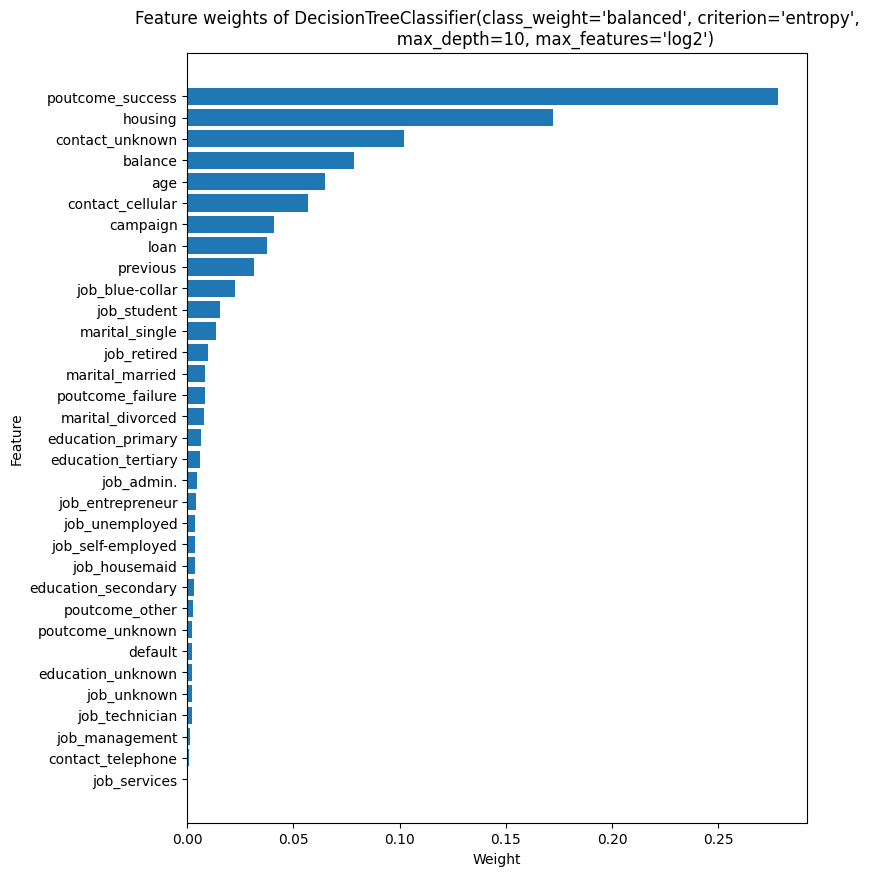

In [ ]:
desc_order = np.argsort(abs(grid_DT.best_estimator_.feature_importances_))

DT_features = list(X.columns[desc_order][:10])

plt.figure(figsize=(8,10))
plt.barh(X.columns[desc_order], abs(grid_DT.best_estimator_.feature_importances_)[desc_order])
plt.title(f'Feature weights of {grid_DT.best_estimator_} ')
plt.ylabel('Feature')
plt.xlabel("Weight")
plt.show()

In [ ]:
# Отбор признаков
sfs = SequentialFeatureSelector(estimator=DecisionTreeClassifier(), n_features_to_select=10, direction='forward')

sfs.fit(X_train_scaled, y_train)

sfs_cols = list(X.columns[sfs.get_support()])

print(f'Отобранные SFS признаки: {sfs_cols}')

Отобранные SFS признаки: ['default', 'housing', 'loan', 'campaign', 'job_student', 'job_unemployed', 'job_unknown', 'contact_unknown', 'poutcome_other', 'poutcome_success']


In [ ]:
model = DecisionTreeClassifier(class_weight='balanced')

params = {
    'max_depth': [3, 5, 7, 10],
    'max_features': [1, 2, 3, 'sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
grid_DT_f = GridSearchCV(
      estimator=model,
      param_grid=params,
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1
  )

grid_DT_f.fit(X_train_scaled[sfs_cols], y_train)

best_idx_DT_f = grid_DT_f.best_index_

print(f'Лучшие параметры DecisionTreeClassifier: {grid_DT_f.best_params_}\n')
print('--- Результаты DecisionTreeClassifier без фильтрации признаков (обучающая выборка) ---\n')
print(f'Accuracy: {grid_DT_f.cv_results_['mean_test_ACC'][best_idx_DT_f]:.4f}')
print(f'Precision: {grid_DT_f.cv_results_['mean_test_PRE'][best_idx_DT_f]:.4f}')
print(f'Recall: {grid_DT_f.cv_results_['mean_test_REC'][best_idx_DT_f]:.4f}')
print(f'F1: {grid_DT_f.cv_results_['mean_test_F1'][best_idx_DT_f]:.4f}')


Лучшие параметры DecisionTreeClassifier: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 3, 'min_samples_split': 5}

--- Результаты DecisionTreeClassifier без фильтрации признаков (обучающая выборка) ---

Accuracy: 0.7467
Precision: 0.2470
Recall: 0.5760
F1: 0.3455


In [ ]:
print(f'Сравнение метрик DecisionTreeClassifier:')
print(f'\n-- До фильтрации --')
print(f'Accuracy: {grid_DT.cv_results_['mean_test_ACC'][best_idx_DT]:.4f}')
print(f'Precision: {grid_DT.cv_results_['mean_test_PRE'][best_idx_DT]:.4f}')
print(f'Recall: {grid_DT.cv_results_['mean_test_REC'][best_idx_DT]:.4f}')
print(f'F1: {grid_DT.cv_results_['mean_test_F1'][best_idx_DT]:.4f}')
print(f'\n-- После фильтрации --')
print(f'Accuracy: {grid_DT_f.cv_results_['mean_test_ACC'][best_idx_DT_f]:.4f}')
print(f'Precision: {grid_DT_f.cv_results_['mean_test_PRE'][best_idx_DT_f]:.4f}')
print(f'Recall: {grid_DT_f.cv_results_['mean_test_REC'][best_idx_DT_f]:.4f}')
print(f'F1: {grid_DT_f.cv_results_['mean_test_F1'][best_idx_DT_f]:.4f}')


Сравнение метрик DecisionTreeClassifier:

-- До фильтрации --
Accuracy: 0.7293
Precision: 0.2373
Recall: 0.5822
F1: 0.3346

-- После фильтрации --
Accuracy: 0.7467
Precision: 0.2470
Recall: 0.5760
F1: 0.3455


**Сравнение метрик:**
Для `DecisionTreeClassifier` при классификации с фильтрацией признаков наблюдается улучшение метрик. Это объясняется тем, что при отборе признаков `SequentialFeatureSelector` использовалась модель `DecisionTreeClassifier`, то есть по сути нелинейные зависимости определялись дважды.



### 4. Случайный лес
   - Построить случайный лес (`RandomForestClassifier`), c использованием `GridSearchCV` осуществить подбор гиперпараметра.
   - Вывести полученные гиперпараметры лучшей модели случайного леса.
   - Осуществить фильтрацию признаков.
   - Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками.
   - Вывести полученные гиперпараметры лучшей модели случайного леса.
   - Сравнить метрики до и после фильтрации признаков лучших моделей.

In [ ]:
model = RandomForestClassifier(class_weight='balanced')

params = {
    'n_estimators': [20, 50, 100, 150],
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy']
}
grid_RF = GridSearchCV(
      estimator=model,
      param_grid=params,
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1,
  )

grid_RF.fit(X_train_scaled, y_train)

best_idx_RF = grid_RF.best_index_

print(f'Лучшие параметры RandomForestClassifier: {grid_RF.best_params_}\n')
print('--- Результаты RandomForestClassifier без фильтрации признаков (обучающая выборка) ---\n')
print(f'Accuracy: {grid_RF.cv_results_['mean_test_ACC'][best_idx_RF]:.4f}')
print(f'Precision: {grid_RF.cv_results_['mean_test_PRE'][best_idx_RF]:.4f}')
print(f'Recall: {grid_RF.cv_results_['mean_test_REC'][best_idx_RF]:.4f}')
print(f'F1: {grid_RF.cv_results_['mean_test_F1'][best_idx_RF]:.4f}')

Лучшие параметры RandomForestClassifier: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 100}

--- Результаты RandomForestClassifier без фильтрации признаков (обучающая выборка) ---

Accuracy: 0.7774
Precision: 0.2791
Recall: 0.5800
F1: 0.3768


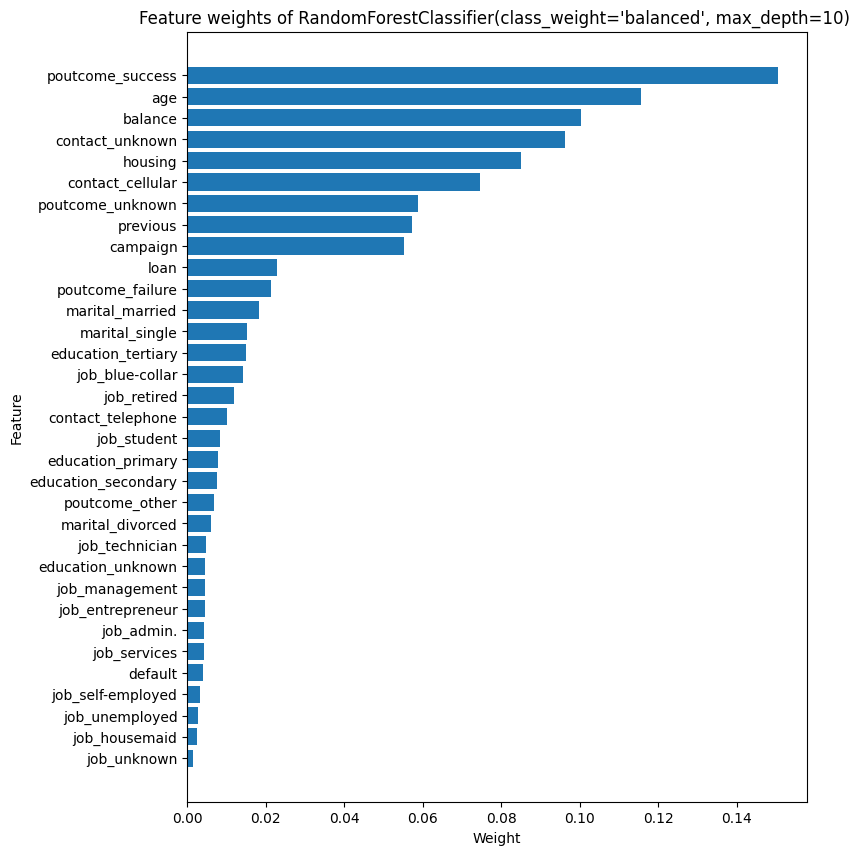

In [ ]:
desc_order = np.argsort(abs(grid_RF.best_estimator_.feature_importances_))

RF_features = list(X.columns[desc_order][:10])

plt.figure(figsize=(8,10))
plt.barh(X.columns[desc_order], abs(grid_RF.best_estimator_.feature_importances_)[desc_order])
plt.title(f'Feature weights of {grid_RF.best_estimator_} ')
plt.ylabel('Feature')
plt.xlabel("Weight")
plt.show()

In [ ]:
model = RandomForestClassifier(class_weight='balanced')

params = {
    'n_estimators': [20, 50, 100, 150],
    'max_depth': [3, 5, 7, 10],
    'criterion': ['gini', 'entropy']
}
grid_RF_f = GridSearchCV(
      estimator=model,
      param_grid=params,
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1,
  )

grid_RF_f.fit(X_train_scaled[sfs_cols], y_train)

y_pred = grid_RF_f.predict(X_test_scaled[sfs_cols])

best_idx_RF_f = grid_RF_f.best_index_

print(f'Лучшие параметры RandomForestClassifier: {grid_RF_f.best_params_}')
print('--- Результаты классификации лучшей моделью RandomForestClassifier с фильтрацией признаков ---\n')
print(f'Accuracy: {grid_RF_f.cv_results_['mean_test_ACC'][best_idx_RF_f]:.4f}')
print(f'Precision: {grid_RF_f.cv_results_['mean_test_PRE'][best_idx_RF_f]:.4f}')
print(f'Recall: {grid_RF_f.cv_results_['mean_test_REC'][best_idx_RF_f]:.4f}')
print(f'F1: {grid_RF_f.cv_results_['mean_test_F1'][best_idx_RF_f]:.4f}')

Лучшие параметры RandomForestClassifier: {'criterion': 'entropy', 'max_depth': 10, 'n_estimators': 50}
--- Результаты классификации лучшей моделью RandomForestClassifier с фильтрацией признаков ---

Accuracy: 0.7440
Precision: 0.2453
Recall: 0.5798
F1: 0.3446


In [ ]:
print(f'Сравнение метрик RandomForestClassifier:')
print(f'\n-- До фильтрации --')
print(f'Accuracy: {grid_RF.cv_results_['mean_test_ACC'][best_idx_RF]:.4f}')
print(f'Precision: {grid_RF.cv_results_['mean_test_PRE'][best_idx_RF]:.4f}')
print(f'Recall: {grid_RF.cv_results_['mean_test_REC'][best_idx_RF]:.4f}')
print(f'F1: {grid_RF.cv_results_['mean_test_F1'][best_idx_RF]:.4f}')
print(f'\n-- После фильтрации --')
print(f'Accuracy: {grid_RF_f.cv_results_['mean_test_ACC'][best_idx_RF_f]:.4f}')
print(f'Precision: {grid_RF_f.cv_results_['mean_test_PRE'][best_idx_RF_f]:.4f}')
print(f'Recall: {grid_RF_f.cv_results_['mean_test_REC'][best_idx_RF_f]:.4f}')
print(f'F1: {grid_RF_f.cv_results_['mean_test_F1'][best_idx_RF_f]:.4f}')


Сравнение метрик RandomForestClassifier:

-- До фильтрации --
Accuracy: 0.7774
Precision: 0.2791
Recall: 0.5800
F1: 0.3768

-- После фильтрации --
Accuracy: 0.7440
Precision: 0.2453
Recall: 0.5798
F1: 0.3446


**Сравнение метрик:**
Для `RandomForestClassifier` при классификации с фильтрацией признаков наблюдается снижение метрик. Это объясняется тем, что случайный лес изначально стремится учитывать максимальное количество информации и обладает устойчивостью к шумам за счет случайного построения деревьев. Заранее же фильтруя признаки мы лишаем его части информации.


### 5. Метод ближайших соседей:
   - С использованием `GridSearchCV` осуществить подбор гиперпараметра `KNeighborsClassifier` (`n_neighbors`).
   - Вывести значения гиперпараметра и метрик для наилучшей модели.
   - Осуществить фильтрацию признаков.
   - Подобрать лучшую модель с использованием `GridSearchCV` на обучающей выборке с отфильтрованными признаками.
   - Вывести полученные гиперпараметры лучшей модели случайного леса.
   - Сравнить метрики до и после фильтрации признаков.

In [ ]:
model = KNeighborsClassifier(weights='distance')

grid_NN = GridSearchCV(
      estimator = model,
      param_grid = {'n_neighbors': [3, 5, 7, 9]},
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1,
  )

grid_NN.fit(X_train_scaled, y_train)

best_idx_NN = grid_NN.best_index_

print(f'Лучшие параметры KNeighborsClassifier: {grid_NN.best_params_}\n')
print('--- Результаты классификации лучшей моделью KNeighborsClassifier без фильтрации признаков ---\n')
print(f'Accuracy: {grid_NN.cv_results_['mean_test_ACC'][best_idx_NN]:.4f}')
print(f'Precision: {grid_NN.cv_results_['mean_test_PRE'][best_idx_NN]:.4f}')
print(f'Recall: {grid_NN.cv_results_['mean_test_REC'][best_idx_NN]:.4f}')
print(f'F1: {grid_NN.cv_results_['mean_test_F1'][best_idx_NN]:.4f}')


In [ ]:
model = KNeighborsClassifier()

grid_NN_f = GridSearchCV(
      estimator=model,
      param_grid = {'n_neighbors': [3, 5, 7, 9]},
      cv=5,
      scoring={'F1':'f1','ACC':'accuracy','PRE':'precision','REC':'recall'},
      refit='F1',
      n_jobs=-1,
  )

grid_NN_f.fit(X_train_scaled[sfs_cols], y_train)

best_idx_NN_f = grid_NN_f.best_index_

print(f'Лучшие параметры KNeighborsClassifier: {grid_NN_f.best_params_}\n')
print('--- Результаты классификации лучшей моделью KNeighborsClassifier с фильтрацией признаков ---\n')
print(f'Accuracy: {grid_NN_f.cv_results_['mean_test_ACC'][best_idx_NN_f]:.4f}')
print(f'Precision: {grid_NN_f.cv_results_['mean_test_PRE'][best_idx_NN_f]:.4f}')
print(f'Recall: {grid_NN_f.cv_results_['mean_test_REC'][best_idx_NN_f]:.4f}')
print(f'F1: {grid_NN_f.cv_results_['mean_test_F1'][best_idx_NN_f]:.4f}')


Лучшие параметры KNeighborsClassifier: {'n_neighbors': 7}

--- Результаты классификации лучшей моделью KNeighborsClassifier с фильтрацией признаков ---

Accuracy: 0.8676
Precision: 0.4542
Recall: 0.2254
F1: 0.2844


In [ ]:
print(f'Сравнение метрик KNeighborsClassifier:')
print(f'\n-- До фильтрации --')
print(f'Accuracy: {grid_NN.cv_results_['mean_test_ACC'][best_idx_NN]:.4f}')
print(f'Precision: {grid_NN.cv_results_['mean_test_PRE'][best_idx_NN]:.4f}')
print(f'Recall: {grid_NN.cv_results_['mean_test_REC'][best_idx_NN]:.4f}')
print(f'F1: {grid_NN.cv_results_['mean_test_F1'][best_idx_NN]:.4f}')
print(f'\n-- После фильтрации --')
print(f'Accuracy: {grid_NN_f.cv_results_['mean_test_ACC'][best_idx_NN_f]:.4f}')
print(f'Precision: {grid_NN_f.cv_results_['mean_test_PRE'][best_idx_NN_f]:.4f}')
print(f'Recall: {grid_NN_f.cv_results_['mean_test_REC'][best_idx_NN_f]:.4f}')
print(f'F1: {grid_NN_f.cv_results_['mean_test_F1'][best_idx_NN_f]:.4f}')


Сравнение метрик KNeighborsClassifier:

-- До фильтрации --
Accuracy: 0.8743
Precision: 0.4184
Recall: 0.2144
F1: 0.2832

-- После фильтрации --
Accuracy: 0.8676
Precision: 0.4542
Recall: 0.2254
F1: 0.2844


**Сравнение метрик**:

При фильтрации признаков метрики классификации `KNeighborsClassifier` изменились неоднозначно. **Accuracy** и **Precision** значительно выросли, **Recall**  снизился, а **F1-мера** незначительно выросла. Сложно сказать, что качество классификации однозначно возросло при фильтрации признаков, из-за того, что в бинарной классификации важна метрика **Recall** при дисбалансе классов, которая в данном случае снизилась.

### 6. Если наблюдается улучшение метрик
Если наблюдается улучшение метрик после фильтрации признаков хотя бы для одной из моделей, то для набора отфильтрованных признаков (пересечение множеств отфильтрованных признаков каждой модели или объединение множеств &ndash; не особо важно, главное описать, каким образом получен новый subset данных) заново построить наилучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier`, сравнить модели в пункте 7 на одинаковом полученном наборе отфильтрованных признаков. Иначе &ndash; пропустить этот пункт.

При фильтрации признаков улучшение метрик наблюдается только для `KNeighborsClassifier`. Построим новый набор признаков, взяв самые важные признаки по feature_importances для `DecisionTreeClassifier` и `RandomForestClassifier` и объединив их с отобранными `SequentialFeatureSelector` признаками, использовавшимися ранее.

In [ ]:
selected_features = list(set(sfs_cols + DT_features + RF_features))

### 7. Оценка качества построенных моделей:
   - Визуализировать любое полученное дерево решений.
     > Для вывода названий признаков в граф необходимо задать значение аргумента `feature_names` в `sklearn.tree.export_graphviz`, для вывода названий классов &ndash; `class_names` (перед кодированием целевого признака можно сохранить названия в отдельный массив).
   - Сравнить лучшие модели `KNeighborsClassifier`, `DecisionTreeClassifier`, `RandomForestClassifier` на **тестовой выборке**. Привести значения метрик $accuracy$, $precision$, $recall$, $\textit{f-measure}$.

In [ ]:
# Построим чуть меньшее дерево для удобства визуализации
tree_model = DecisionTreeClassifier(max_depth=3)

tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3)

In [ ]:
pip install graphviz

In [ ]:
# используем .dot формат для визуализации дерева
sklearn.tree.export_graphviz(
    tree_model,
    feature_names = X.columns,
    out_file = f'tree.dot',
    class_names = ['no', 'yes'],
    filled = True
)

# для выполнения следующей команды нужен установленный GraphViz
!dot -Tpng tree.dot -o tree.png

NameError: name 'sklearn' is not defined

In [ ]:
plt.figure(figsize=(15, 10))
plt.imshow(iio.imread_v2('tree.png'))
plt.axis('off')
plt.show()

In [ ]:
DT_best = DecisionTreeClassifier(**grid_DT.best_params_)
RF_best = RandomForestClassifier(**grid_RF.best_params_)
NN_best = KNeighborsClassifier(**grid_NN.best_params_)

DT_best.fit(X_train_scaled[selected_features], y_train)
RF_best.fit(X_train_scaled[selected_features], y_train)
NN_best.fit(X_train_scaled[selected_features], y_train)


print_classification_metrics(DT_best)
print_classification_metrics(RF_best)
print_classification_metrics(NN_best)

**Итоговое сравнение**:

Как можно видеть по значениям метрик, на заданных датасете и отобраннных признаках все модели показывают схожие результаты. Если же выбирать лучшую модель, то ей будет `RandomForestClassifier`, у которого все значения метрик выше, чем у остальных моделей.